# Predictive Maintenance Classification Pipeline

This notebook is a guided implementation template for the Module 1 assessment.  
It follows the required execution order: EDA, data preparation, feature engineering, train/test split, training-set-only resampling, KNN scaling, Decision Tree without scaling, hyperparameter comparison, overfitting analysis, and final accuracy-based verdict.

Renan de Brito Leme

## 0. Environment Setup

In [41]:
# ============================================================
# RF00 - Libraries import
# ============================================================

import numpy as np
import pandas as pd
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Resampling
from imblearn.over_sampling import SMOTE
# Alternative if SMOTE is too slow or unavailable:
# from imblearn.under_sampling import RandomUnderSampler

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
sns.set_context("notebook")

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Environment configured successfully.")

Environment configured successfully.


## 1. Load the Dataset

In [42]:
DATA_PATH = "predictive_maintenance.csv"
raw_dataset = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")
print("Shape:", raw_dataset.shape)
raw_dataset.head()

Dataset loaded successfully.
Shape: (10000, 14)


,udi,product_id,machine_type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,heat_dissipation_failure,power_failure,overstrain_failure,random_failure
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


## 2. Data Dictionary and Modeling Assumptions

Important modeling assumptions:

1. `machine_failure` is the binary target variable.
2. The columns `tool_wear_failure`, `heat_dissipation_failure`, `power_failure`, `overstrain_failure`, and `random_failure` are specific failure causes and must not be used as predictors because they would leak information about the target.
3. `udi` and `product_id` are identifiers, not physical process variables, so they should also be excluded from the model.
4. The relevant predictors are equipment type and sensor/process variables.

In [43]:
target_column = "machine_failure"

identifier_columns = ["unique_id", "product_id"]

leakage_columns = [
    "tool_wear_failure",
    "heat_dissipation_failure",
    "power_failure",
    "overstrain_failure",
    "random_failure",
]

numeric_sensor_features = [
    "air_temperature_k",
    "process_temperature_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min",
]

categorical_features = ["machine_type"]

print("Target column:", target_column)
print("Identifier columns:", identifier_columns)
print("Leakage columns:", leakage_columns)
print("Numeric sensor features:", numeric_sensor_features)
print("Categorical features:", categorical_features)

Target column: machine_failure
Identifier columns: ['unique_id', 'product_id']
Leakage columns: ['tool_wear_failure', 'heat_dissipation_failure', 'power_failure', 'overstrain_failure', 'random_failure']
Numeric sensor features: ['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min']
Categorical features: ['machine_type']


# Phase 1 — Exploratory Data Analysis (EDA)

Required outputs:

- Dataset dimensions.
- Variable data types.
- Descriptive statistics with `.describe()`.
- At least three analytical plots.
- A written interpretation connecting the EDA findings to modeling decisions.

In [44]:
print("Dataset shape:", raw_dataset.shape)
raw_dataset.info()
print("-------------------------------------------------------")
print("Data types:")
print(raw_dataset.dtypes)

Dataset shape: (10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   udi                       10000 non-null  int64  
 1   product_id                10000 non-null  str    
 2   machine_type              10000 non-null  str    
 3   air_temperature_k         9500 non-null   float64
 4   process_temperature_k     9500 non-null   float64
 5   rotational_speed_rpm      9500 non-null   float64
 6   torque_nm                 9500 non-null   float64
 7   tool_wear_min             10000 non-null  int64  
 8   machine_failure           10000 non-null  int64  
 9   tool_wear_failure         10000 non-null  int64  
 10  heat_dissipation_failure  10000 non-null  int64  
 11  power_failure             10000 non-null  int64  
 12  overstrain_failure        10000 non-null  int64  
 13  random_failure            10000 non-null  int6

In [45]:
raw_dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
udi,10000.0,5000.500000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
air_temperature_k,9500.0,300.002158,2.001689,295.3,298.30,300.1,301.50,304.5
process_temperature_k,9500.0,310.000895,1.486432,305.7,308.80,310.1,311.10,313.8
rotational_speed_rpm,9500.0,1539.245263,180.273589,1168.0,1423.00,1504.0,1613.00,2886.0
torque_nm,9500.0,39.974168,9.995453,3.8,33.10,40.1,46.70,76.6
tool_wear_min,10000.0,107.951000,63.654147,0.0,53.00,108.0,162.00,253.0
machine_failure,10000.0,0.033900,0.180981,0.0,0.00,0.0,0.00,1.0
tool_wear_failure,10000.0,0.004600,0.067671,0.0,0.00,0.0,0.00,1.0
heat_dissipation_failure,10000.0,0.011500,0.106625,0.0,0.00,0.0,0.00,1.0
power_failure,10000.0,0.009500,0.097009,0.0,0.00,0.0,0.00,1.0


In [46]:
# Missing values overview
missing_summary = pd.DataFrame({
    "missing_count": raw_dataset.isna().sum(),
    "missing_percent": raw_dataset.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_percent
process_temperature_k,500,5.0
air_temperature_k,500,5.0
rotational_speed_rpm,500,5.0
torque_nm,500,5.0
product_id,0,0.0
udi,0,0.0
machine_type,0,0.0
tool_wear_min,0,0.0
machine_failure,0,0.0
tool_wear_failure,0,0.0


In [47]:
# Target distribution
target_distribution = raw_dataset[target_column].value_counts().sort_index()

target_percentage = (
    raw_dataset[target_column]
    .value_counts(normalize=True)
    .sort_index() * 100
)

target_summary = pd.DataFrame({
    "count": target_distribution,
    "percentage": target_percentage.round(2),
})

target_summary

,count,percentage
machine_failure,,
0,9661,96.61
1,339,3.39


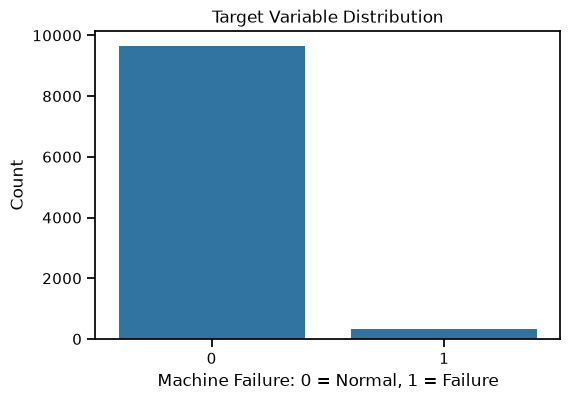

  Chart exported: outputs\target_variable_distribution.png


In [48]:
# Plot 1: target imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=raw_dataset, x=target_column)
plt.title("Target Variable Distribution")
plt.xlabel("Machine Failure: 0 = Normal, 1 = Failure")
plt.ylabel("Count")
output_dir="outputs"
file_path = os.path.join(output_dir, "target_variable_distribution.png")
plt.savefig(file_path, dpi=150)
plt.show()
plt.close()
print(f"  Chart exported: {file_path}")

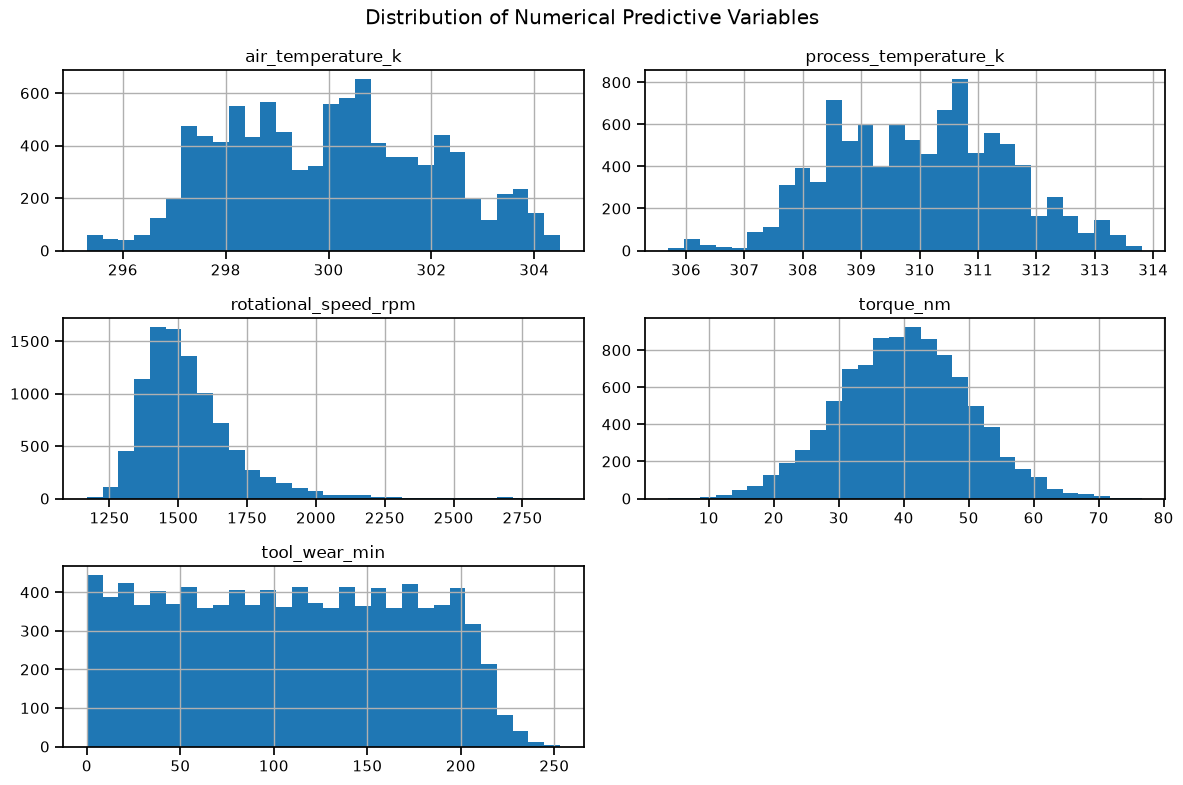

  Chart exported: outputs\distribution_of_numerical_predictive_variables.png


In [49]:
# Plot 2: numerical variable distributions
raw_dataset[numeric_sensor_features].hist(figsize=(12, 8), bins=30)
plt.suptitle("Distribution of Numerical Predictive Variables")
plt.tight_layout()
output_dir="outputs"
file_path = os.path.join(output_dir, "distribution_of_numerical_predictive_variables.png")
plt.savefig(file_path, dpi=150)
plt.show()
plt.close()
print(f"  Chart exported: {file_path}")

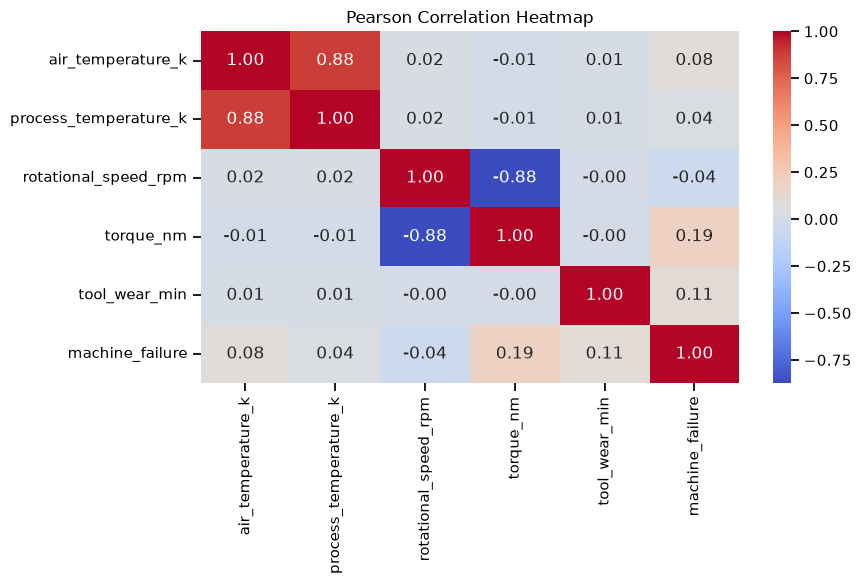

  Chart exported: outputs\pearson_correlation_heatmap.png


In [50]:
# Plot 3: Pearson correlation heatmap
correlation_columns = numeric_sensor_features + [target_column]
correlation_matrix = raw_dataset[correlation_columns].corr(numeric_only=True)

plt.figure(figsize=(9, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
output_dir="outputs"
file_path = os.path.join(output_dir, "pearson_correlation_heatmap.png")
plt.savefig(file_path, dpi=150)
plt.show()
plt.close()
print(f"  Chart exported: {file_path}")

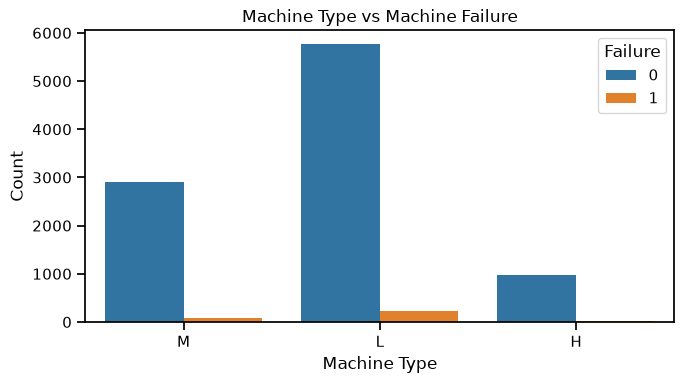

  Chart exported: outputs\machine_type_vs_machine_failure.png


In [51]:
# Plot 4: equipment type vs target
plt.figure(figsize=(7, 4))
sns.countplot(
    data=raw_dataset,
    x="machine_type",
    hue=target_column
)
plt.title("Machine Type vs Machine Failure")
plt.xlabel("Machine Type")
plt.ylabel("Count")
plt.legend(title="Failure")
plt.tight_layout()
output_dir="outputs"
file_path = os.path.join(output_dir, "machine_type_vs_machine_failure.png")
plt.savefig(file_path, dpi=150)
plt.show()
plt.close()
print(f"  Chart exported: {file_path}")

### EDA Interpretation

- The target variable is highly imbalanced, so resampling will be required after the train/test split.
- Missing values appear in sensor variables, so imputation is required before modeling.
- Because some numerical features may be skewed and industrial sensor data can contain outliers, median imputation is a robust option.
- KNN will require scaling because it depends on distance calculations.
- Decision Trees do not require scaling because they split variables by thresholds.
- Failure-cause columns must be excluded to prevent data leakage.

# Phase 2 — Data Cleaning and Preparation

Required outputs:

- Identify and remove duplicated rows.
- Identify missing values.
- Apply mean or median imputation with a written justification.
- Create boxplots to inspect outliers in explanatory variables.

In [52]:
# Duplicate rows
duplicate_count = raw_dataset.duplicated().sum()
print("Duplicate rows before cleaning:", duplicate_count)

clean_dataset = raw_dataset.drop_duplicates().copy()
print("Shape before duplicate removal:", raw_dataset.shape)
print("Shape after duplicate removal:", clean_dataset.shape)

Duplicate rows before cleaning: 0
Shape before duplicate removal: (10000, 14)
Shape after duplicate removal: (10000, 14)


In [53]:
# Missing values after duplicate removal
clean_dataset.isna().sum().sort_values(ascending=False)

process_temperature_k       500
air_temperature_k           500
rotational_speed_rpm        500
torque_nm                   500
product_id                    0
udi                           0
machine_type                  0
tool_wear_min                 0
machine_failure               0
tool_wear_failure             0
heat_dissipation_failure      0
power_failure                 0
overstrain_failure            0
random_failure                0
dtype: int64

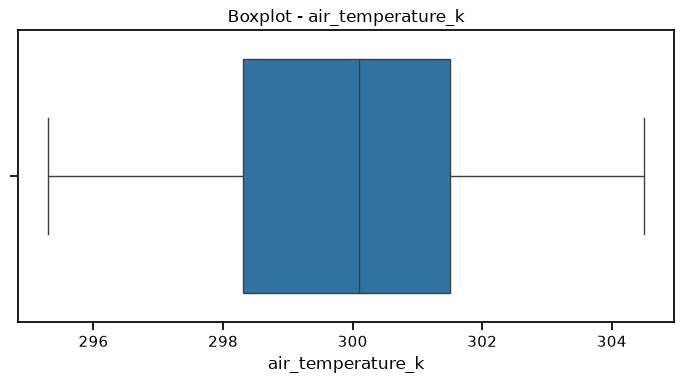

  Chart exported: outputs\Boxplot_air_temperature_k.png


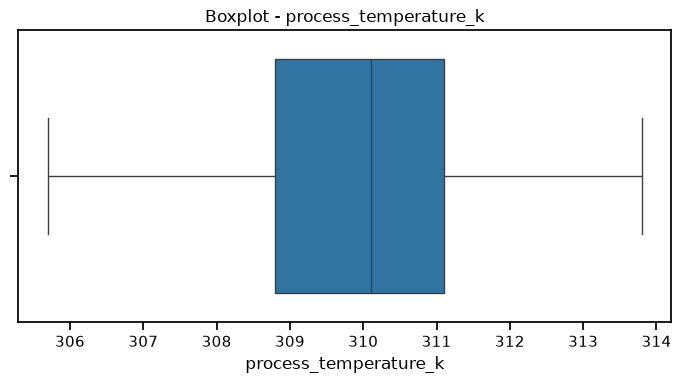

  Chart exported: outputs\Boxplot_process_temperature_k.png


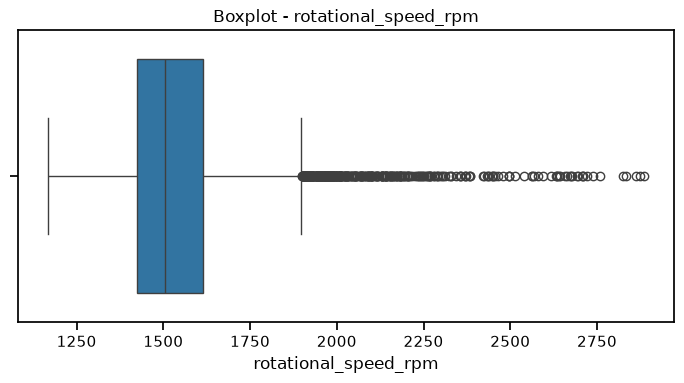

  Chart exported: outputs\Boxplot_rotational_speed_rpm.png


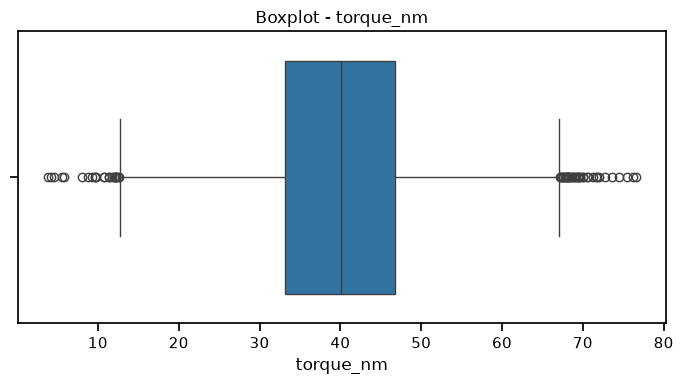

  Chart exported: outputs\Boxplot_torque_nm.png


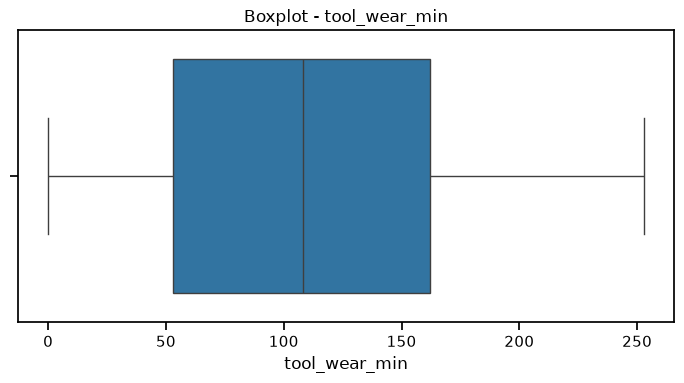

  Chart exported: outputs\Boxplot_tool_wear_min.png


In [54]:
# Boxplots for outlier inspection before imputation
for feature in numeric_sensor_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(
    data=clean_dataset,
    x=feature
    )
    plt.title(f"Boxplot - {feature}")
    plt.xlabel(feature)
    plt.tight_layout()
    output_dir="outputs"
    file_path = os.path.join(output_dir, f"Boxplot_{feature}.png")
    plt.savefig(file_path, dpi=150)
    plt.show()
    plt.close()
    print(f"  Chart exported: {file_path}")

### Outlier Decision

Outliers were retained because unusual sensor values may represent meaningful abnormal operating conditions associated with failure rather than data-entry errors.

# Phase 3 — Train/Test Split Before Learned Transformations

Required outputs:

- Separate predictors `X` from target `y`.
- Split into training and test sets using 80/20.
- Use `stratify=y`.
- Apply resampling only to the training data to avoid data leakage.

In [55]:
base_feature_columns=numeric_sensor_features+categorical_features

X_raw=clean_dataset[base_feature_columns].copy()
y=clean_dataset[target_column].copy()

print("Base predictor columns:",base_feature_columns)
print("X_raw shape:",X_raw.shape);
print("y shape:",y.shape)

Base predictor columns: ['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'machine_type']
X_raw shape: (10000, 6)
y shape: (10000,)


In [56]:
X_train_raw,X_test_raw,y_train,y_test=train_test_split(
    X_raw,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("X_train_raw shape:",X_train_raw.shape)
print("X_test_raw shape:",X_test_raw.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(4))

X_train_raw shape: (8000, 6)
X_test_raw shape: (2000, 6)

Training target distribution:
machine_failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

Test target distribution:
machine_failure
0    0.966
1    0.034
Name: proportion, dtype: float64


# Phase 4 — Training-Fitted Imputation

In [57]:
# Phase 4 — Training-Fitted Imputationnumeric_imputer=SimpleImputer(strategy="median")
numeric_imputer=SimpleImputer(strategy="median")
categorical_imputer=SimpleImputer(strategy="most_frequent")

X_train_imputed=X_train_raw.copy();
X_test_imputed=X_test_raw.copy();

X_train_imputed[numeric_sensor_features]=numeric_imputer.fit_transform(X_train_raw[numeric_sensor_features])
X_test_imputed[numeric_sensor_features]=numeric_imputer.transform(X_test_raw[numeric_sensor_features])

X_train_imputed[categorical_features]=categorical_imputer.fit_transform(X_train_raw[categorical_features])
X_test_imputed[categorical_features]=categorical_imputer.transform(X_test_raw[categorical_features])

print("Missing after imputation - train:",int(X_train_imputed.isna().sum().sum()))
print("Missing after imputation - test:",int(X_test_imputed.isna().sum().sum()))

Missing after imputation - train: 0
Missing after imputation - test: 0


In [58]:
imputation_summary=pd.DataFrame({
    "feature":numeric_sensor_features,
    "training_median":numeric_imputer.statistics_
})
imputation_summary

,feature,training_median
0,air_temperature_k,300.1
1,process_temperature_k,310.1
2,rotational_speed_rpm,1503.5
3,torque_nm,40.1
4,tool_wear_min,107.0


### Imputation Justification

The imputers are fitted only on training data. Median imputation is used for numerical variables because it is less affected by extreme values than the mean. The most frequent category is used for `machine_type`.

# Phase 5 — Feature Engineering After Imputation

The new feature `power_proxy` is created using the suggested mathematical operation:

`power_proxy = rotational_speed_rpm * torque_nm`# Phase 3 - Feature Engineering


An additional feature, `temperature_difference_k`, is also created to represent the difference between process temperature and air temperature.

In [59]:
def add_engineered_features(dataset: pd.DataFrame) -> pd.DataFrame:
    result=dataset.copy()
    result["power_proxy"]=result["rotational_speed_rpm"]*result["torque_nm"]
    result["temperature_difference_k"]=result["process_temperature_k"]-result["air_temperature_k"]
    return result

X_train_engineered=add_engineered_features(X_train_imputed)
X_test_engineered=add_engineered_features(X_test_imputed)
engineered_features=["power_proxy","temperature_difference_k"]
print("Engineered features:",engineered_features)

Engineered features: ['power_proxy', 'temperature_difference_k']


In [60]:
for name,dataset in {"training":X_train_engineered,"test":X_test_engineered}.items():
    missing=int(dataset[engineered_features].isna().sum().sum())
    infinite=int(np.isinf(dataset[engineered_features]).sum().sum())
    print(f"{name.capitalize()} - missing: {missing}, infinite: {infinite}")
X_train_engineered[engineered_features].describe().T

Training - missing: 0, infinite: 0
Test - missing: 0, infinite: 0


,count,mean,std,min,25%,50%,75%,max
power_proxy,8000.0,60002.960675,9992.097703,10966.8,53470.425,60290.35,66531.15,99980.4
temperature_difference_k,8000.0,9.998100,0.973085,7.6,9.300,9.90,10.90,12.1


### Feature Engineering Interpretation

The `power` feature combines rotational speed and torque. In an industrial maintenance context, the combination of high rotational speed and high torque can indicate higher mechanical demand. The `temperature_difference` feature measures the difference between process temperature and ambient air temperature, which can help represent heat generation during operation.

# Phase 6 — Training-Fitted One-Hot Encoding

The categorical feature `machine_type` has three categories: `L`, `M`, and `H`.

Using One-Hot Encoding to create only two columns:

- `machine_type_L`
- `machine_type_M`

or another pair depending on the alphabetical order of the categories in the dataset.

The removed category becomes the reference category. If both dummy columns are zero, the machine belongs to the reference type.

In [61]:
one_hot_encoder=OneHotEncoder(
    categories=[["L","M","H"]],drop=["L"],handle_unknown="ignore",sparse_output=False,dtype=int
)
train_encoded_array=one_hot_encoder.fit_transform(X_train_engineered[categorical_features])
test_encoded_array=one_hot_encoder.transform(X_test_engineered[categorical_features])
one_hot_features=one_hot_encoder.get_feature_names_out(categorical_features).tolist()
X_train_encoded=pd.DataFrame(train_encoded_array,columns=one_hot_features,index=X_train_engineered.index)
X_test_encoded=pd.DataFrame(test_encoded_array,columns=one_hot_features,index=X_test_engineered.index)
print("One-Hot columns:",one_hot_features)

One-Hot columns: ['machine_type_M', 'machine_type_H']


In [62]:
continuous_features=numeric_sensor_features+engineered_features
X_train_prepared=pd.concat([X_train_engineered[continuous_features],X_train_encoded],axis=1)
X_test_prepared=pd.concat([X_test_engineered[continuous_features],X_test_encoded],axis=1)
print("Prepared training shape:",X_train_prepared.shape)
print("Prepared test shape:",X_test_prepared.shape)
print(X_train_prepared.columns.tolist())

Prepared training shape: (8000, 9)
Prepared test shape: (2000, 9)
['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'power_proxy', 'temperature_difference_k', 'machine_type_M', 'machine_type_H']


### Training-Fitted One-Hot Encoding Interpretation

The categorical variable machine_type was transformed using One-Hot Encoding. This technique converts the categorical machine types into binary variables (machine_type_M and machine_type_H), allowing machine learning algorithms to process categorical information without imposing any ordinal relationship between categories. The L category was explicitly selected as the reference category (drop=["L"]), so observations with both dummy variables equal to zero correspond to machines of type L. This approach avoids redundant information (dummy variable trap), reduces multicollinearity, and enables the models to evaluate the influence of each machine type on the probability of machine failure.

# Phase 7 — Decision Tree Branch and KNN Branch

Required outputs:

- Apply `StandardScaler` only for KNN.
- Use `fit_transform` on training data and `transform` on test data.
- Keep Decision Tree data without scaling.
- Explain why Decision Trees are scale-insensitive.

In [63]:
# Decision Tree Branch
smote_tree=SMOTE(random_state=RANDOM_STATE)

X_train_tree,y_train_tree=smote_tree.fit_resample(X_train_prepared,y_train)
X_test_tree=X_test_prepared.copy()

print("Before SMOTE:")
print(y_train.value_counts())
print("Tree training shape before SMOTE:", X_train_prepared.shape)

print("\nAfter SMOTE:")
print(y_train_tree.value_counts())
print("Tree training shape after SMOTE:", X_train_tree.shape)

print("Tree test shape:", X_test_tree.shape)

Before SMOTE:
machine_failure
0    7729
1     271
Name: count, dtype: int64
Tree training shape before SMOTE: (8000, 9)

After SMOTE:
machine_failure
0    7729
1    7729
Name: count, dtype: int64
Tree training shape after SMOTE: (15458, 9)
Tree test shape: (2000, 9)


In [64]:
# KNN Branch
scaler=StandardScaler()

X_train_knn_scaled=X_train_prepared.copy();
X_test_knn=X_test_prepared.copy()

X_train_knn_scaled[continuous_features]=scaler.fit_transform(
    X_train_prepared[continuous_features])
X_test_knn[continuous_features]=scaler.transform(
    X_test_prepared[continuous_features])

smote_knn=SMOTE(random_state=RANDOM_STATE)
X_train_knn,y_train_knn=smote_knn.fit_resample(
    X_train_knn_scaled,
    y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_knn.value_counts())

X_train_knn_scaled[continuous_features].agg(["mean", "std"]).T

Before SMOTE:
machine_failure
0    7729
1     271
Name: count, dtype: int64

After SMOTE:
machine_failure
0    7729
1    7729
Name: count, dtype: int64


,mean,std
air_temperature_k,6.981082e-15,1.000063
process_temperature_k,3.377831e-14,1.000063
rotational_speed_rpm,1.714184e-16,1.000063
torque_nm,-1.065814e-17,1.000063
tool_wear_min,-3.064216e-17,1.000063
power_proxy,5.151435e-16,1.000063
temperature_difference_k,-2.233769e-15,1.000063


### Scaling and Resampling Justification

The KNN scaler is fitted on real training observations before SMOTE, so synthetic samples do not influence the learned mean and standard deviation. SMOTE is then applied in the scaled feature space. The Decision Tree uses encoded but unscaled data because threshold-based splits are insensitive to feature scale.

# Phase 8 — Hyperparameter Tuning and Overfitting Analysis

Required outputs:

- Train KNN using at least three odd values of `n_neighbors`.
- Train Decision Tree using at least three values of `max_depth`.
- Record training and test accuracy.
- Identify overfitting points and the most stable configuration.

In [65]:
knn_results=[]

for neighbors in [3,5,7,9,11]:
    model=KNeighborsClassifier(
        n_neighbors=neighbors
    )
    model.fit(X_train_knn,y_train_knn)
    train_pred=model.predict(X_train_knn);
    test_pred=model.predict(X_test_knn)
    train_acc=accuracy_score(y_train_knn,train_pred);
    test_acc=accuracy_score(y_test,test_pred)
    knn_results.append({
        "model":"KNN",
        "n_neighbors":neighbors,
        "train_accuracy":train_acc,
        "test_accuracy":test_acc,
        "accuracy_gap":train_acc-test_acc
    })
    
knn_results_df=pd.DataFrame(knn_results_df.round(4))
knn_results_df.sort_values(
    by="test_accuracy",
    ascending=False
)

,model,n_neighbors,train_accuracy,test_accuracy,accuracy_gap
0,KNN,3,0.9792,0.937,0.0422
1,KNN,5,0.9683,0.929,0.0393
2,KNN,7,0.9626,0.916,0.0466
3,KNN,9,0.9580,0.913,0.0450
4,KNN,11,0.9539,0.901,0.0529


In [66]:
tree_results=[]

for depth in [3,5,7,10,None]:
    model=DecisionTreeClassifier(
        max_depth=depth,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_tree,y_train_tree)
    train_pred=model.predict(X_train_tree);
    test_pred=model.predict(X_test_tree)
    train_acc=accuracy_score(y_train_tree,train_pred);
    test_acc=accuracy_score(y_test,test_pred)
    tree_results.append({
        "model":"Decision Tree",
        "max_depth":depth,
        "train_accuracy":train_acc,
        "test_accuracy":test_acc,
        "accuracy_gap":train_acc-test_acc})
    
tree_results_df=pd.DataFrame(tree_results).round(4)
tree_results_df.sort_values(
    by="test_accuracy",
    ascending=False
)

,model,max_depth,train_accuracy,test_accuracy,accuracy_gap
4,Decision Tree,NaN,0.9995,0.9495,0.0500
3,Decision Tree,10.0,0.9403,0.9320,0.0083
2,Decision Tree,7.0,0.9112,0.9170,-0.0058
1,Decision Tree,5.0,0.8905,0.9130,-0.0225
0,Decision Tree,3.0,0.8638,0.8645,-0.0007


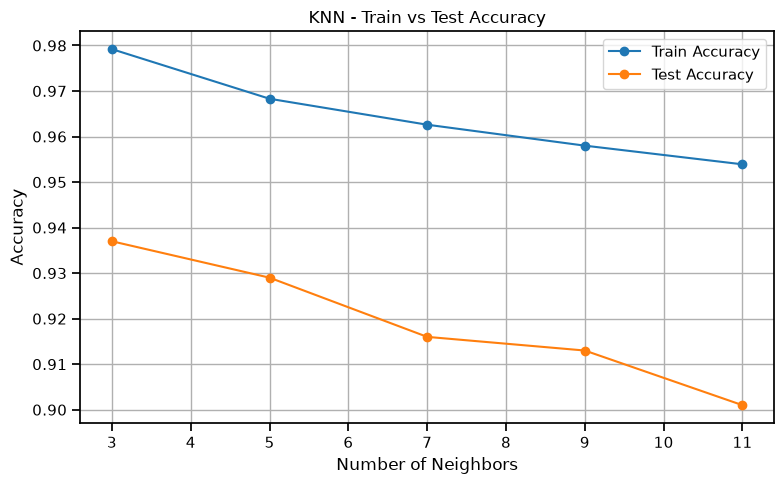

Chart exported: outputs\knn_train_vs_test_accuracy.png


In [67]:
plt.figure(figsize=(8,5))
plt.plot(knn_results_df["n_neighbors"],knn_results_df["train_accuracy"],marker="o",label="Train Accuracy")
plt.plot(knn_results_df["n_neighbors"],knn_results_df["test_accuracy"],marker="o",label="Test Accuracy")
plt.title("KNN - Train vs Test Accuracy"); plt.xlabel("Number of Neighbors"); plt.ylabel("Accuracy")
plt.legend();
plt.grid(True);
plt.tight_layout()
file_path=os.path.join(OUTPUT_DIR,"knn_train_vs_test_accuracy.png")
plt.savefig(file_path,dpi=150,bbox_inches="tight");
plt.show();
plt.close();
print(f"Chart exported: {file_path}")

In [68]:
best_knn_row=knn_results_df.sort_values(["test_accuracy","accuracy_gap"],ascending=[False,True]).iloc[0]
best_tree_row=tree_results_df.sort_values(["test_accuracy","accuracy_gap"],ascending=[False,True]).iloc[0]
print("Best KNN configuration:");
print(best_knn_row)
print("\nBest Decision Tree configuration:");
print(best_tree_row)

Best KNN configuration:
model                KNN
n_neighbors            3
train_accuracy    0.9792
test_accuracy      0.937
accuracy_gap      0.0422
Name: 0, dtype: object

Best Decision Tree configuration:
model             Decision Tree
max_depth                   NaN
train_accuracy           0.9995
test_accuracy            0.9495
accuracy_gap               0.05
Name: 4, dtype: object


### Overfitting Interpretation

The training and test accuracies were compared to assess the models' ability to generalize. A large difference between these values indicates overfitting, meaning the model has learned the training data too specifically and performs worse on unseen data. For KNN, very small values of n_neighbors increase model complexity and sensitivity to noise, while for Decision Trees, allowing unlimited depth (max_depth=None) can produce overly complex trees that memorize the training data. The most appropriate configuration is therefore the one that achieves high test accuracy while maintaining a small train-test accuracy gap, indicating a good balance between predictive performance and generalization.

# Phase 9 — Final Accuracy Evaluation and Verdict

Required outputs:

- Final test accuracy of the best KNN.
- Final test accuracy of the best Decision Tree.
- Numerical comparison.
- Final decision on which model should be adopted by the company.

In [69]:
# Best KNN selection
best_neighbors=int(best_knn_row["n_neighbors"])
best_knn_model=KNeighborsClassifier(n_neighbors=best_neighbors)
best_knn_model.fit(X_train_knn,y_train_knn)
best_knn_predictions=best_knn_model.predict(X_test_knn)
best_knn_accuracy=accuracy_score(y_test,best_knn_predictions)
print("Best KNN n_neighbors:",best_neighbors)
print("Best KNN test accuracy:",round(best_knn_accuracy,4))

Best KNN n_neighbors: 3
Best KNN test accuracy: 0.937


In [70]:
# Best Decision Tree selection
best_tree_depth_raw=best_tree_row["max_depth"]
best_tree_depth= None if pd.isna(best_tree_depth_raw) else int(best_tree_depth_raw)
best_tree_model=DecisionTreeClassifier(
    max_depth=best_tree_depth,
    random_state=RANDOM_STATE
)
best_tree_model.fit(X_train_tree,y_train_tree)
best_tree_predictions=best_tree_model.predict(X_test_tree)
best_tree_accuracy=accuracy_score(y_test,best_tree_predictions)
print("Best Decision Tree max_depth:",best_tree_depth)
print("Best Decision Tree test accuracy:",round(best_tree_accuracy,4))

Best Decision Tree max_depth: None
Best Decision Tree test accuracy: 0.9495


In [71]:
# Final model comparison
final_comparison = pd.DataFrame([
    {
        "model": "KNN",
        "best_hyperparameter": f"n_neighbors={best_neighbors}",
        "test_accuracy": best_knn_accuracy,
    },
    {
        "model": "Decision Tree",
        "best_hyperparameter": f"max_depth={best_tree_depth}",
        "test_accuracy": best_tree_accuracy,
    },
])

final_comparison.sort_values("test_accuracy", ascending=False)

,model,best_hyperparameter,test_accuracy
1,Decision Tree,max_depth=None,0.9495
0,KNN,n_neighbors=3,0.9370


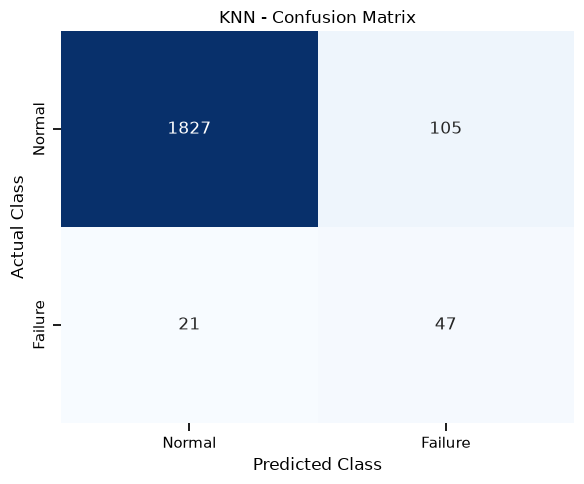

Chart exported: outputs\knn_confusion_matrix.png


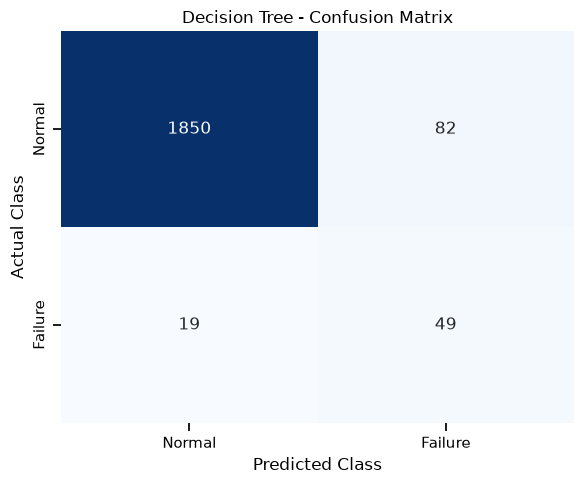

Chart exported: outputs\decision_tree_confusion_matrix.png

KNN Classification Report:


,precision,recall,f1-score,support
Normal,0.9886,0.9457,0.9667,1932.000
Failure,0.3092,0.6912,0.4273,68.000
accuracy,0.9370,0.9370,0.9370,0.937
macro avg,0.6489,0.8184,0.6970,2000.000
weighted avg,0.9655,0.9370,0.9483,2000.000



Decision Tree Classification Report:


,precision,recall,f1-score,support
Normal,0.9898,0.9576,0.9734,1932.0000
Failure,0.3740,0.7206,0.4925,68.0000
accuracy,0.9495,0.9495,0.9495,0.9495
macro avg,0.6819,0.8391,0.7329,2000.0000
weighted avg,0.9689,0.9495,0.9571,2000.0000


Recommended model: Decision Tree
Selected test accuracy: 0.9495
Reason: Decision Tree achieved the higher test accuracy with max_depth=None.


In [73]:
# Evaluation - Confusion Matrices and Reports
# 1. Confusion matrices
models_predictions = {
    "KNN": best_knn_predictions,
    "Decision Tree": best_tree_predictions,
}

for model_name, predictions in models_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Normal", "Failure"],
        yticklabels=["Normal", "Failure"]
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.tight_layout()

    file_name = (
        model_name.lower()
        .replace(" ", "_")
        + "_confusion_matrix.png"
    )

    file_path = os.path.join(OUTPUT_DIR, file_name)

    plt.savefig(
        file_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print(f"Chart exported: {file_path}")

# 2. Classification reports as DataFrames
knn_report = classification_report(
    y_test,
    best_knn_predictions,
    target_names=["Normal", "Failure"],
    output_dict=True,
    zero_division=0
)

tree_report = classification_report(
    y_test,
    best_tree_predictions,
    target_names=["Normal", "Failure"],
    output_dict=True,
    zero_division=0
)

knn_report_df = pd.DataFrame(knn_report).T.round(4)
tree_report_df = pd.DataFrame(tree_report).T.round(4)

print("\nKNN Classification Report:")
display(knn_report_df)

print("\nDecision Tree Classification Report:")
display(tree_report_df)


# 3. Comparison focused on the minority class
failure_comparison = pd.DataFrame([
    {
        "model": "KNN",
        "accuracy": best_knn_accuracy,
        "failure_precision": knn_report["Failure"]["precision"],
        "failure_recall": knn_report["Failure"]["recall"],
        "failure_f1_score": knn_report["Failure"]["f1-score"],
    },
    {
        "model": "Decision Tree",
        "accuracy": best_tree_accuracy,
        "failure_precision": tree_report["Failure"]["precision"],
        "failure_recall": tree_report["Failure"]["recall"],
        "failure_f1_score": tree_report["Failure"]["f1-score"],
    },
]).round(4)

failure_comparison

# 4. Recommended model
if best_knn_accuracy>best_tree_accuracy:
    selected_model="KNN"; 
    selected_accuracy=best_knn_accuracy
    reason=f"KNN achieved the higher test accuracy with n_neighbors={best_neighbors}."
elif best_tree_accuracy>best_knn_accuracy:
    selected_model="Decision Tree";
    selected_accuracy=best_tree_accuracy
    reason=f"Decision Tree achieved the higher test accuracy with max_depth={best_tree_depth}."
else:
    if float(best_tree_row["accuracy_gap"])<=float(best_knn_row["accuracy_gap"]):
        selected_model="Decision Tree";
        selected_accuracy=best_tree_accuracy
        reason="Both models tied on test accuracy, but the Decision Tree had an equal or smaller train-test gap and is easier to interpret."
    else:
        selected_model="KNN";
        selected_accuracy=best_knn_accuracy
        reason="Both models tied on test accuracy, but KNN had the smaller train-test gap."
print("Recommended model:",selected_model)
print("Selected test accuracy:",round(selected_accuracy,4))
print("Reason:",reason)

### Final Verdict

The final model should primarily be selected based on the highest test accuracy between the best KNN and the best Decision Tree. The train-test accuracy gap should also be considered to assess generalization and identify possible overfitting. If both models achieve similar test accuracy, the model with the smaller train-test gap should be preferred. In the case of comparable predictive performance, the Decision Tree may be recommended because its decision rules are easier to interpret in an industrial maintenance context. Although accuracy is the primary metric required by the project, precision, recall, and F1-score should also be examined because machine failure represents the minority class and accuracy alone may hide poor failure-detection performance.

### Complementary Analysis — Feature Importance

In [78]:
feature_importance_df=pd.DataFrame({
    "feature":X_train_prepared.columns,
    "importance":best_tree_model.feature_importances_,
}).sort_values("importance",ascending=False)
feature_importance_df

,feature,importance
2,rotational_speed_rpm,0.305719
5,power_proxy,0.254994
4,tool_wear_min,0.213652
6,temperature_difference_k,0.059056
7,machine_type_M,0.044429
1,process_temperature_k,0.044331
0,air_temperature_k,0.034208
3,torque_nm,0.023044
8,machine_type_H,0.020567


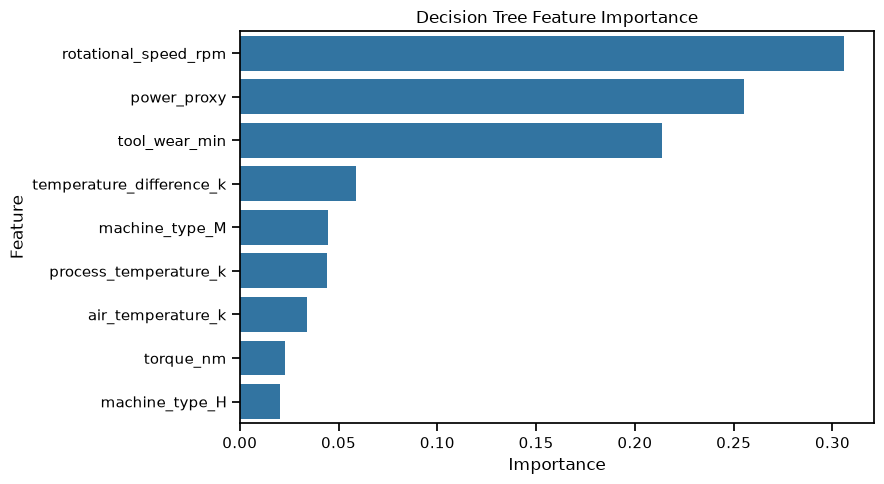

Chart exported: outputs\decision_tree_feature_importance.png


In [79]:
plt.figure(figsize=(9,5))
sns.barplot(data=feature_importance_df,x="importance",y="feature")
plt.title("Decision Tree Feature Importance"); plt.xlabel("Importance"); plt.ylabel("Feature")
plt.tight_layout()
file_path=os.path.join(OUTPUT_DIR,"decision_tree_feature_importance.png")
plt.savefig(file_path,dpi=150,bbox_inches="tight"); plt.show(); plt.close(); print(f"Chart exported: {file_path}")

### Final Technical Summary
- Imputers, encoder, and scaler are fitted only on training data.
- Decision Tree branch: encoded data → SMOTE → unscaled tree.
- KNN branch: encoded data → StandardScaler → SMOTE → KNN.
- Test data is transformed with training-fitted parameters and is never resampled.
